# Lab075 · PyTorch Frame: the row encoder

**Skill:** use the real PyTorch Frame API to produce typed column tokens and row vectors. This is the tool/API exception: a framework composition lab, not a paper benchmark reproduction. TierC five-type fixture isolates mechanisms; TierA credit_g uses actual numeric/categorical columns. No accuracy claim. Complete the TODOs, pass CHECKs and export row vectors with their schema.

[Lesson](../lessons/0075-pytorch-frame-row-encoder.html) · [Contract](../labs/l075-reproduction.md)

### Running on Google Colab?

Colab opens only this single file, so the course package (`relkit`) and the lab
dependencies (xgboost, lightgbm, catboost, …) are **not** present by default. The cell
below fixes that: on Colab it shallow-clones the course repo, installs
`requirements-labs.txt`, and switches into `labs/` so `relkit` imports and the data cache
resolve. **On a local venv or your own Jupyter it does nothing — just run it and continue.**

In [ ]:
# @colab-bootstrap — PROVIDED. Makes the lab self-sufficient on Google Colab; a no-op elsewhere.
import os, sys

if "google.colab" in sys.modules:
    if not os.path.isdir("/content/relational"):
        !git clone --depth 1 https://github.com/Avistian/relational.git /content/relational
    %pip install -q -r /content/relational/requirements-labs.txt
    os.chdir("/content/relational/labs")
    print("Colab ready — working dir:", os.getcwd())
else:
    print("Not on Colab — using the local environment as-is.")

In [ ]:
# PROVIDED — version is part of the behavior contract.
import importlib.metadata
assert importlib.metadata.version('pytorch-frame') == '0.3.0', 'Install pytorch-frame==0.3.0 in this kernel'


## Start with retrieval

Before reading, write three short answers from memory. What distinguishes a numeric feature token from a category lookup in L046? What information does a within-row CARTE graph omit about a relational database? Why must a fitted transformation be learned without looking at the test set? Keep these answers for your exit ticket.



**Today’s tangible win:** take a table containing numbers, categories, text, timestamps and stored vectors; produce a typed `TensorFrame`, column tokens and one vector per row; explain which operations learned from which rows. Plan for 35–45 minutes of reading and prediction, then 30–45 minutes in the lab.

> **In plain terms.** A database row contains several kinds of information. Before a neural network can use it, each kind needs an appropriate translator. PyTorch Frame organizes those translators and their outputs. It does not decide which information was legally available at prediction time.

This advances our mission at a specific seam: the representation of each database row **before** a GNN exchanges information along relationships. L074’s [CARTE lesson](../lessons/0074-carte-cross-table-transfer.html) handled schema-variable row graphs. Here we deliberately use a fixed schema and explicit type assignments. L076 will connect row vectors to relationships between records.

<!-- depth-walkthrough:start -->
<div class="learning-route"><p class="route-kicker">THE BIG PICTURE · LESSON 075</p><p><strong>Build on what you know.</strong> Lessons 44–46 built column tokenizers inside specific architectures; <a href="https://avistian.github.io/relational/lessons/0074-carte-cross-table-transfer.html">Lesson 74</a> attached semantic meaning to cells. Here we separate conversion, learned encoding and row readout so each boundary can be inspected.</p><p><strong>The next question.</strong> <a href="https://avistian.github.io/relational/lessons/0076-encoder-predictor-stack.html">Lesson 76</a> uses the resulting vectors as node states. A row encoder must preserve identity as well as width, otherwise correct graph arithmetic can send the wrong record to a neighbor.</p><p><a href="https://avistian.github.io/relational/reference/0071-0090-model-map.html">Open the SSL → relational → graph model map</a> · Work the cold retrieval first, then spend 15–20 minutes tracing this overview before the detailed mechanism and lab.</p></div>



## A row representation is an interface with state

<figure class="model-map"><div class="model-map-scroll" tabindex="0" role="region" aria-label="Architecture diagram; scroll horizontally on narrow screens">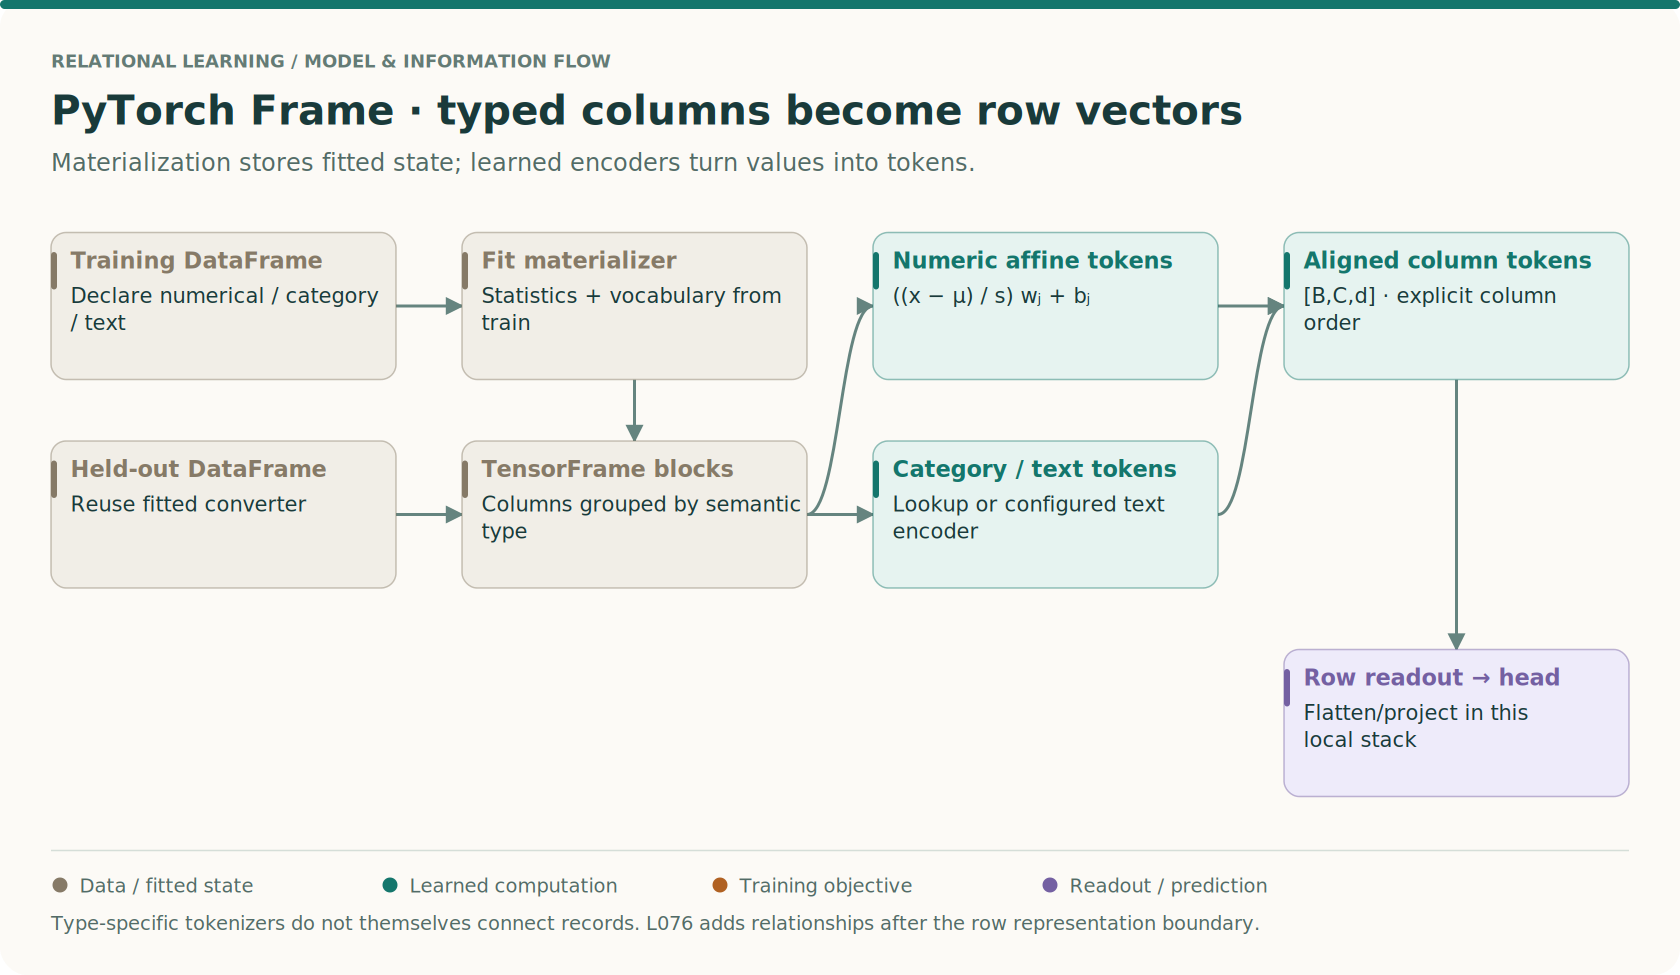</div><figcaption>Read the arrows as data dependencies. Teal: learned computation; amber: training objective; violet: readout or prediction. This is a computation overview; exact settings and paper/release differences are specified below.</figcaption></figure>

### Read the framework from left to right

Read [PyTorch Frame Figure 1 and §3](https://arxiv.org/html/2404.00776v2#S3). The figure describes separable components, not a promise that one default model is appropriate for every schema. Distinguish a materialized tensor, a column token, a row embedding and a prediction. All four may be floating-point arrays, but they answer different questions.

### Trace a train row and a query row together

1. **Assign meaning before choosing a dtype.** A customer identifier stored as an integer is not automatically a numerical measurement. A category encoded as 17 should not imply “twice category 8.5.” Declare semantic types from the problem, then choose the corresponding conversion.
2. **Fit conversion state on training rows.** Store vocabulary addresses, numerical statistics and missing-value policies. Transform a query using this stored state. Refitting on a query batch can move category addresses or change scaling even when no query labels are used.
3. **Produce per-column tokens.** For one numerical column use μ=20, s=10, w=[2,−1], b=[0.5,0.5]. Values 20 and 30 become [0.5,0.5] and [2.5,−0.5]. The statistics determine the input coordinate system; learned w and b determine how the model uses that coordinate.
4. **Retain column identity.** Two columns with equal scalar values need not produce equal tokens because their learned parameters differ. A [B,C,d] tensor therefore contains C positioned column representations, not an unordered bag unless the subsequent architecture explicitly treats it that way.
5. **Specify the readout.** Flattening yields [B,Cd] and binds the head to a schema. Pooling yields a fixed width but can discard distinctions. Attention creates another interaction rule. The local flatten/project readout is an explicit choice, not something guaranteed by materialization itself.

<details><summary>Check: a missing value becomes the numerical bias—why?</summary><p>Under the configured mean-imputation policy, x is replaced by μ. Its standardized value is zero, so the affine token is 0·w+b=b. This is a consequence of this policy; another missing-value strategy can behave differently.</p></details>

**Your intermediate artifact:** save a tiny schema card with each column's semantic type, fitted state, missing-value behavior and token position. Change a held-out value and verify that the card's fitted statistics do not change.

<!-- depth-walkthrough:end -->



## 1. Semantic type is a modeling decision

A **data type** tells software how a value is stored: integer, floating-point number, string, datetime. A **semantic type**, abbreviated **stype**, tells the model how to interpret a column. Integer `101` might be an amount, a postal region, or a record identifier. The storage alone cannot settle that decision.

**Worked example.** The value `20` in an amount column has meaningful distance from `10`. The code `20` in a region column need not be twice region `10`. A numeric encoder gives the former a continuous direction. A categorical encoder gives the latter a lookup vector. Changing the stype changes the computation even when the underlying values stay identical.

| Column in our fixture | Meaning | User-facing stype in release 0.3.0 | Operation |
|---|---|---|---|
| `amount` | A measured scalar | `numerical` | Normalize, then a column-specific affine map |
| `region` | A discrete label | `categorical` | Training vocabulary → integer → embedding lookup |
| `note` | A short description | `text_embedded` | Fixed text adapter → stored vector → learned projection |
| `created` | Calendar time | `timestamp` | Calendar components → positional/cyclic features → projection |
| `vector` | An already computed representation | `embedding` | Column-specific projection to a common width |

A **projection** is a learned linear map that changes vector coordinates and often their number. An **embedding** is a vector used to represent a value. A category’s integer ID is an address into a learned embedding table; its numeric distance is not a model assumption.

The [paper, §3](https://arxiv.org/html/2404.00776v2#S3) introduces the semantic-type abstraction. Be careful with spelling: the paper describes `text_embedding`, whereas our [pinned release enum](https://github.com/pyg-team/pytorch-frame/blob/d998aae368db6a4e36139ccc56bd54579a70874b/torch_frame/_stype.py) exposes `text_embedded`. Copy executable names from the version you actually install.

**Stop and classify.** Would you encode `customer_id` as a continuous number? Usually no: subtraction between arbitrary IDs has no meaningful units. Would a timestamp automatically prevent leakage? No: a timestamp describes a value; eligibility still needs an explicit cutoff. Do not include a label or a post-outcome measurement among the predictors merely because you can assign it a stype.



## 2. Materialization creates data, not learned row vectors

**Materialization** converts a DataFrame into the tensor-friendly containers expected by the model. A `Dataset` manages the raw frame, type assignments, fitted column statistics and conversion. A `TensorFrame` holds converted feature blocks plus their column-name metadata, and optionally targets.

> **In plain terms.** Materialization packs values into boxes that PyTorch can process. It has not yet learned what makes a useful prediction.

For a batch containing **B rows**, materialization groups columns by their parent semantic type. It preserves the association between each column and its role. Let **C** be the number of feature columns and **d** the common token width. The different raw blocks need not be ordinary tensors of the same shape. Only **after encoding** do we require one dense tensor of shape `[B, C, d]`.

**Worked example.** Our training fixture has four rows. `amount` is `[10, 20, 30, missing]`, while the categorical vocabulary contains `north` and `south`. The note `red apple` becomes `[1, 0, 1, 0]` under the lab’s explicitly provided vocabulary `[red, green, apple, pear]`. The stored vector has three coordinates. These two vector columns have different widths, so they cannot be naively stacked as a rectangular `[B, 2, width]` tensor.

The release uses a `MultiEmbeddingTensor` container for variable-width embedding columns. It groups `text_embedded` under its parent `embedding`, retaining the column identity and individual dimension. The encoder therefore has **four parent-type configurations for five columns**. Our measured token order is `amount, region, created, vector, note`. Do not assume that the original DataFrame order survives grouping. Use the names returned with the encoded tensor.

<figure><div class="figure-scroll" tabindex="0" role="region" aria-label="Scrollable types diagram">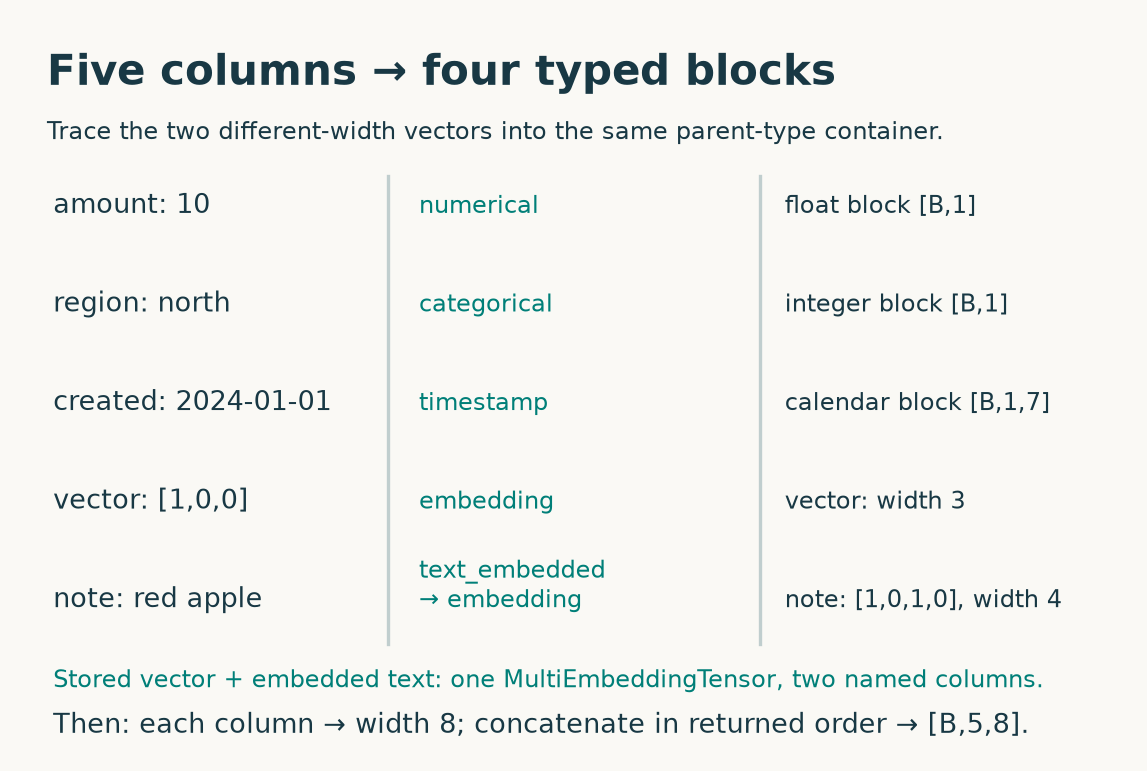</div><figcaption>Synthetic five-column fixture: text width4 and stored-vector width3 share the embedding parent type, then each receives a width8 token. B denotes rows. Scroll the diagram horizontally on narrow screens.</figcaption></figure>

The [release converter](https://github.com/pyg-team/pytorch-frame/blob/d998aae368db6a4e36139ccc56bd54579a70874b/torch_frame/data/dataset.py) determines these groups. The [heterogeneous-types tutorial](https://pytorch-frame.readthedocs.io/en/latest/handling_advanced_stypes/handle_heterogeneous_stypes.html) shows how to configure encoders, but its latest version may differ from our pinned package.

**Text choices.** With `text_embedded`, a fixed adapter turns each string into a vector during conversion. Downstream training learns the projection of that vector; it does not backpropagate through the earlier materialization step into the text model. With `text_tokenized`, conversion retains token information for a text model that can participate in later training. The lab executes the first path only. Its four-word adapter is a transparent teaching fixture, not a language model: `blue fruit` becomes all zeros because neither word is in its vocabulary.

**Check your understanding.** Is a five-column table guaranteed to create five separate `feat_dict` keys? No. Columns share a parent type. Is a zero text vector equivalent to missing text? Not necessarily. Here it means no vocabulary matches; the learned embedding projection can still add its bias.



## 3. Fit the materializer on training rows

A **fitted statistic** depends on the rows used to estimate it: a mean, standard deviation, category vocabulary, or timestamp range. At evaluation time those fitted quantities must represent the training information permitted by the protocol.

The pinned `Dataset.materialize()` computes statistics from the DataFrame supplied to that dataset. Its `split_col` records split membership; it does **not** restrict this computation to the training partition. Splitting a materialized dataset afterward retains the earlier fitted state. This is a source-checked behavior, not an inference from the name of the method.



**Worked example.** Training values are `10, 20, 30, NaN`. Ignoring the missing value gives a mean of `60 / 3 = 20`. A held-out value of `1000` changes an all-row mean to `(60 + 1000) / 4 = 265`. Merely assigning that row split ID `2` does not change the all-row calculation. The learner must control the fit scope.

<figure><div class="figure-scroll" tabindex="0" role="region" aria-label="Scrollable scope diagram">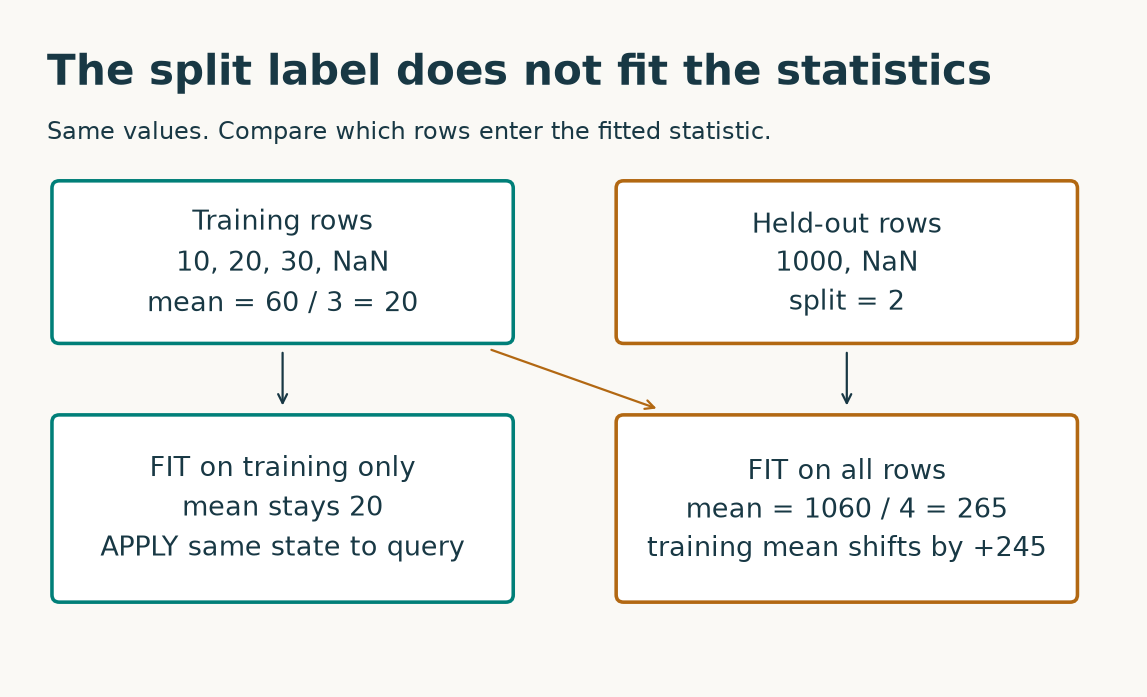</div><figcaption>Exact fit-scope intervention: missing values are ignored for this mean. Holding training values fixed, adding held-out1000 changes the all-row mean from20 to265. Scroll the diagram horizontally on narrow screens.</figcaption></figure>



The safe contract has two operations: construct and materialize the dataset using training rows; then call its fitted `convert_to_tensor_frame` on query rows. The latter is a converter property that is itself callable. It uses the training vocabulary and statistics. The student implements this contract in the first TODO.

A **query row** is a row to encode with the fitted state; in an evaluation it might belong to validation or test. The fixture’s query is an intervention, not a scored test set. The real-data exercise also withholds labels: it checks representation plumbing rather than prediction accuracy.

**What stays fixed?** Training rows, type assignments, encoder weights and text vocabulary. **What changes?** A held-out numeric value. **What do we measure?** Whether the fitted training mean changes. This isolates access to held-out data without conflating it with optimization or model quality.

**Failure case.** Running a fresh `Dataset(query).materialize()` also fails the contract: it estimates a new vocabulary and statistics on query rows. A category might acquire a different integer address. A row can receive a different representation simply because a second query row changed. Reuse the fitted converter; do not independently fit each batch.



## 4. From typed blocks to column tokens

A **token** here is a learned vector for one column value. It is not necessarily a word or text token. `StypeWiseFeatureEncoder` dispatches each block to the appropriate encoder and concatenates the outputs along the column axis. Every column now has the same width, even though the original inputs did not.

### Numeric path: normalize, then map

> **In plain terms.** Express an amount relative to typical training amounts, then let the model learn what a unit change should do to its vector.

For column j, let μⱼ be its training mean, sⱼ its training standard deviation plus the release’s `1e-6` stabilizer, wⱼ a learned vector of width d, and bⱼ a learned bias of the same width. A row’s numeric token is `tⱼ = ((xⱼ − μⱼ) / sⱼ) wⱼ + bⱼ`. Each numeric column has its own w and b. Normalization statistics are stored state; w and b are trainable parameters.

**Worked example.** Use illustrative μ=20, s=10, w=`[2, −1]`, b=`[0.5, 0.5]`. For x=30, the normalized value is 1, so the token is `[2.5, −0.5]`. For x=20, it is `[0.5, 0.5]`. These deliberately chosen parameters make arithmetic visible; they are not the initialized lab weights or its computed standard deviation.

<figure><div class="figure-scroll" tabindex="0" role="region" aria-label="Scrollable numeric diagram">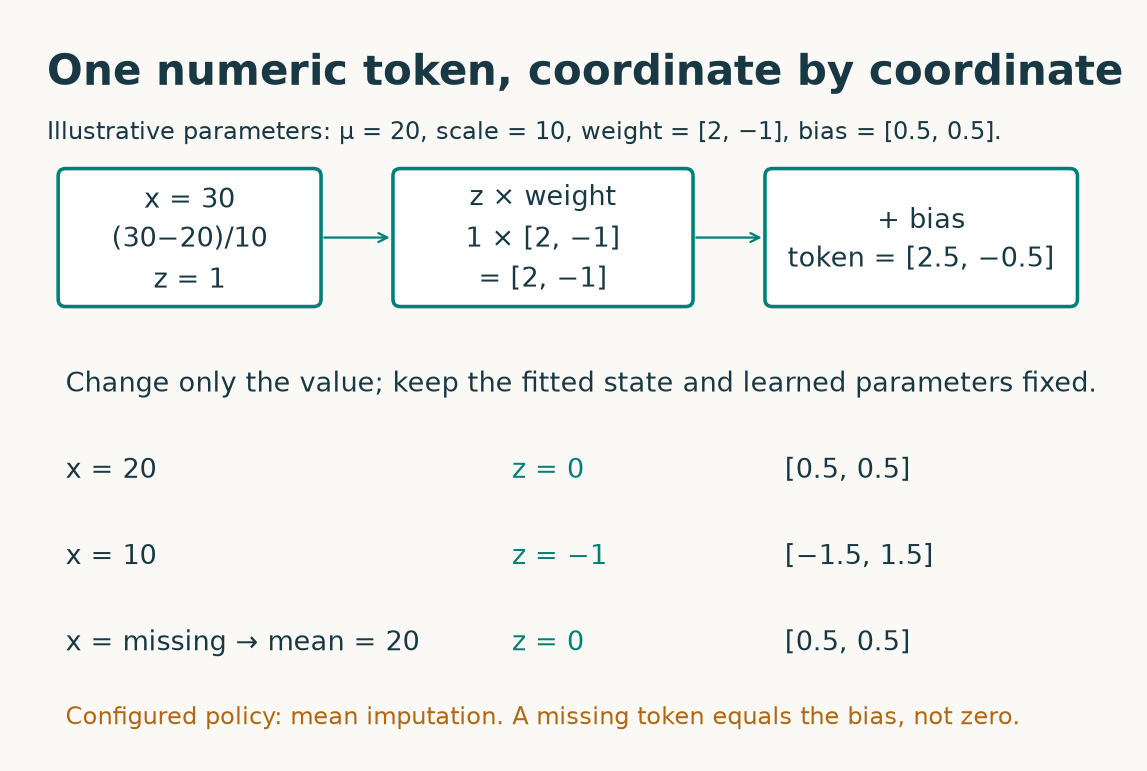</div><figcaption>Illustrative parameters, not the measured fixture standard deviation. Trace normalization, multiplication and bias. Mean imputation makes missing tokens equal the bias. Scroll the diagram horizontally on narrow screens.</figcaption></figure>



Our configured numeric encoder uses `NAStrategy.MEAN`. It replaces missing x with μ before normalization; a missing numeric token therefore equals **b**, not necessarily zero. The package’s default `na_strategy=None` instead lets missing values propagate through the affine map and zeroes NaN outputs afterward. These are distinct behaviors. The lab explicitly chooses mean imputation and checks finite gradients. It does not claim that a zeroed forward output alone proves safe training.

The second mechanism TODO reconstructs the normalized affine operation using broadcasted tensor arithmetic. A **broadcast** lets dimensions of size one align with larger dimensions: `[B,C,1] × [1,C,d]` yields `[B,C,d]`. We check both a hand-calculated oracle and equality with the configured package encoder. The [source](https://github.com/pyg-team/pytorch-frame/blob/d998aae368db6a4e36139ccc56bd54579a70874b/torch_frame/nn/encoder/stype_encoder.py) is the version-specific authority for normalization and missing policies.

### Category path: addresses and unknowns

The training converter builds a vocabulary for each categorical column. Materialized IDs start at zero; unseen and missing values map to `−1`. The configured `EmbeddingEncoder` shifts valid IDs, adds a per-column offset, and sends negative IDs to a shared padding entry. With the default missing strategy that padding embedding is zero.

**Worked example.** Query `region=east` was absent during fitting; query `region=None` is missing. Both materialize as `−1`, and both yield a zero region token. The model therefore cannot distinguish those two causes from that token alone. If the distinction matters, create an explicit, protocol-valid indicator before fitting. Do not invent a learned unseen-category vector and attribute it to this default encoder.

### Timestamp and stored-vector paths

A timestamp is decomposed into seven calendar components in this release. The encoder represents the year relative to the training minimum year and uses cyclic encodings for recurring components. A **cyclic encoding** puts the start and end of a repeating period near one another. Learned weights combine these intermediate features into d coordinates. Missing timestamps use the configured default median training timestamp. The lab checks a missing timestamp and a later year; neither grants permission to access future information.

An embedding column has its own projection from its original width into d coordinates. The note adapter produces width 4; `vector` has width 3; both become width 8. Sharing the `embedding` parent type means sharing the encoder machinery, not necessarily sharing one weight matrix between columns.

**Predict.** If d doubles, which dimension changes in the numeric, category and timestamp outputs? The last one. Does materializing a timestamp make it a learned width-d token? No; its calendar representation must still pass through the encoder.



## 5. A row encoder needs a readout

A feature encoder returns `[B,C,d]`, not automatically `[B,D]`. **D** is the desired width of the final row representation. A **readout** combines a row’s column representations into that vector. Different tabular architectures make different choices about column interaction and readout.

The [paper’s Figure 1 and §§3.2–3.4](https://arxiv.org/html/2404.00776v2#S3) separate encoding, column interaction and decoding. PyTorch Frame is a framework for composing these stages, not a single model with one mandatory prediction function.

### Model architecture: the exact teaching composition

Our lab uses an intentionally small, visible composition. The official feature encoder produces `[B,5,8]`. Flattening joins each row’s five tokens into `[B,40]` without mixing rows. A learned linear layer maps 40 values to 16; a ReLU replaces negative activations with zero; a final linear layer maps 16 to D=6. That is the complete row encoder used for the fixture. A two-output linear head is added only for a gradient-flow check.

<figure><div class="figure-scroll" tabindex="0" role="region" aria-label="Scrollable architecture diagram">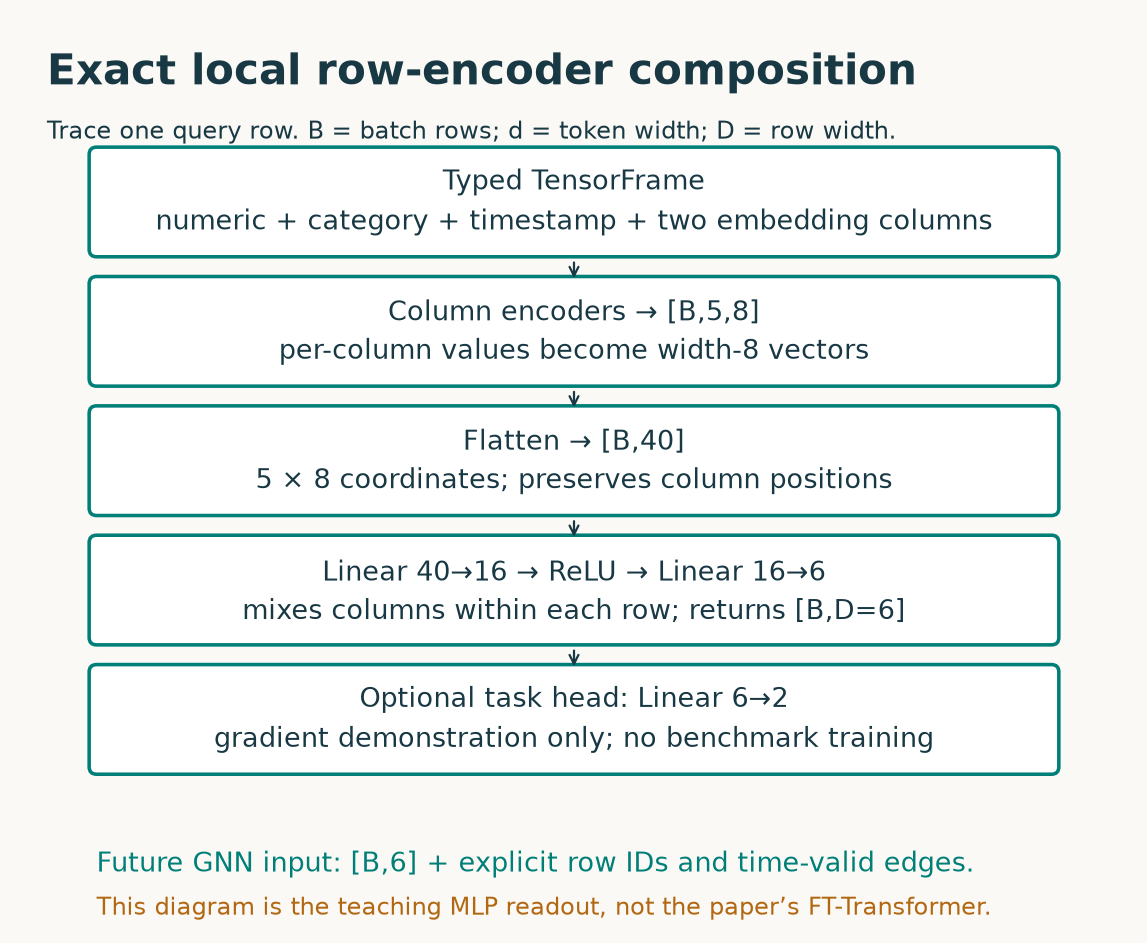</div><figcaption>Complete local teaching composition. Column mixing occurs inside the flattened MLP. No cross-row message passing or benchmark training is pictured. Scroll the diagram horizontally on narrow screens.</figcaption></figure>

The hidden linear layer mixes information across columns because each hidden unit reads all 40 coordinates. Flattening keeps column positions distinguishable. It consequently requires a stable fitted schema: arbitrary reordering of token positions changes the function. Reordering **DataFrame columns** is safe only because the fitted converter restores the schema; this is not proof of arbitrary schema transfer.

The lab checks **row locality**: encoding a query row alone agrees with encoding it in a batch. This composition has no operation that exchanges information between rows. A separate GNN can consume the resulting vectors and edges later. That GNN needs explicit row-to-node identity, foreign-key edges and a time-valid sampling policy. None are supplied by `TensorFrame` itself.

**Gradient check.** A gradient tells a parameter how a differentiable loss changes when the parameter changes. We place a linear head on the row vectors, compute a scalar loss and call `backward()`. Finite gradients reaching the stype encoders establish that the composed path can be optimized. They do not establish good accuracy or correct temporal sampling. The fixed text adapter and categorical vocabulary remain outside that learned path.

> **Scope check.** This MLP readout is a teaching composition, not a reproduction of the paper’s FT-Transformer or relational GraphSAGE experiments. The lesson’s skill is the PyTorch Frame API, using the workspace’s explicit tool/API exception to model-from-scratch requirements. The independent numeric reconstruction makes one load-bearing operation inspectable; the full framework is the library being learned.



## 6. What we actually verified

**Author-reference evidence, measured locally.** These values are saved audit results, not outputs from your current notebook kernel.

| Check | Observed | What it establishes |
|---|---|---|
| Five-type query tokens | `[2, 5, 8]` | One width8 token per column |
| Five-type query rows | `[2, 6]` | Readout returns one width6 vector per row |
| Fitted numeric standard deviation | 8.164966 | Training population SD; encoder adds1e-6 |
| Numeric primitive maximum absolute error | 0.0e+00 | Forward parity on this fixture |
| Training mean: train-only / all rows | 20 / 265 | Split-column metadata does not enforce fit scope |
| Unknown and missing region IDs | −1 / −1 | Both enter default category padding |
| Real credit_g tokens / row vectors | `[32, 20, 8]` / `[32, 16]` | Actual mixed-schema encoding, no accuracy claim |
| Gradient flow, row locality, column reorder | PASS | Tested configured composition behaves as described |

**Evidence limits:** no trained benchmark, no pretrained language model, no relational message passing. Browser and notebook execution have their own delivery reports. Paper-result parity is INCOMPARABLE.


The real-data lane uses **credit_g, OpenML 31**: a small real table already cached for earlier lessons. A label-blind permutation with seed 75 chooses 128 fitting rows and 32 query rows. Numeric and categorical columns use their actual values. No fake timestamps or text columns are attached to make a real dataset appear multimodal. The five-type synthetic fixture isolates the modalities absent from this table.

Both lanes export the schema and row tensors. The real-data model is randomly initialized; those row vectors are a verified interface artifact, not a trained useful representation. There are no accuracy claims, method rankings or confidence intervals to infer from their coordinates. Repeating seeds would describe arbitrary initialization variation rather than comparative predictive performance.

The installed implementation is compared byte-for-byte with selected files at release commit `d998aae368db6a4e36139ccc56bd54579a70874b`. That verifies the code whose behavior we teach. It does not date the release to the paper’s experiments. The paper’s single-table, text and relational results remain cited results, **NOT_RUN** locally. Our API trace is **INCOMPARABLE** to those benchmark tables.

Read the [reproduction contract](../labs/l075-reproduction.md) for versions, exact commands and the boundary between paper, release and local evidence. Reproduce the local audit with `python _verify_l075.py` from `labs/`. Consult the [pinned source ledger](../labs/_sources_l075.json) before upgrading the package.



## 7. Lab: implement, perturb, explain

[Read the lab](../labs/html/0075-pytorch-frame-row-encoder.html) · [Download student notebook](../labs/0075-pytorch-frame-row-encoder.ipynb) · [Reference card](../reference/0075-pytorch-frame-row-encoder.html)

**TODO 1 — Fit scope.** Implement materialization on training rows and conversion of query rows. CHECK perturbs only query values and tests that training statistics stay fixed.

**TODO 2 — Encoder dispatch.** Configure all required parent-type encoders, including mean imputation for numeric values. CHECK requires five finite column tokens and the expected behavior of an unseen category.

**TODO 3 — Numeric tokens.** Implement the mean-imputed normalized affine map. CHECK compares a hand-worked example and package outputs. A parity failure means you must inspect shape, epsilon, missing policy and column order before proceeding.

**RUN — Real schema.** Encode the real credit_g rows and save `l075-row-encoder.pt` plus `l075-schema.json`. The output must identify the row IDs, package version, stypes and token order. Save the encoder state too if those vectors will be consumed later.

**EXIT — Explain without the page.** Submit the output shapes and your files, then answer: why do five columns need four encoder keys? Why does setting a split column not prevent fitted-statistic leakage? Which missing values become bias tokens and which become zero tokens under this configuration? Why is a row vector not yet a relational prediction? What must be frozen and saved to encode a future row consistently?

**Mastery gate.** All CHECK cells pass; the artifacts preserve schema and row identity; each of those five explanations states the actual configured behavior. Running the notebook is not sufficient. Ask me follow-up questions or paste your exit ticket for feedback. Creation of this lesson does not mark it as learned.



## Primary reading and next step

Read [Hu et al., PyTorch Frame, Figure 1 and §3](https://arxiv.org/html/2404.00776v2), then inspect [the pinned feature encoder](https://github.com/pyg-team/pytorch-frame/blob/d998aae368db6a4e36139ccc56bd54579a70874b/torch_frame/nn/encoder/stypewise_encoder.py). Trace one numeric column all the way to its slice of the token tensor. For general API orientation, use the [official introduction](https://pytorch-frame.readthedocs.io/en/latest/get_started/introduction.html), checking version differences against the local source ledger.

Tomorrow, reconstruct the four stages from memory before reopening this page. In the next lesson, keep the row encoder fixed and add explicit relationships between two tables. Predict which row vectors should change after one message-passing step and which should remain untouched.


<a id="lab-exercises"></a>
## Implement and trace

Run from `labs/` locally. The shared Colab bootstrap configures this directory after publication. No cloud model download is needed; the text adapter is deliberately transparent. Provided package encoders are the API being learned. The readout and all composition code are visible below.

In [ ]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch_frame import stype, NAStrategy
from torch_frame.config import TextEmbedderConfig
from torch_frame.data import Dataset
from torch_frame.nn import (StypeWiseFeatureEncoder, LinearEncoder,
                            EmbeddingEncoder, LinearEmbeddingEncoder, TimestampEncoder)
torch.set_num_threads(1)
torch.manual_seed(75)

### PROVIDED · exact data and fixed text adapter

Four training rows, two query rows. The fixed vocabulary has never fitted query data. Predict which query string produces no vocabulary matches.

In [ ]:
def fixture():
    train = pd.DataFrame({
        'amount': [10., 20., 30., np.nan],
        'region': ['north', 'north', 'south', 'south'],
        'note': ['red apple', 'green apple', 'red pear', 'green pear'],
        'created': pd.to_datetime(['2024-01-01','2024-01-02','2024-02-01','2024-02-02']),
        'vector': [[1.,0.,0.],[0.,1.,0.],[0.,0.,1.],[1.,1.,0.]],
    })
    query = pd.DataFrame({
        'amount': [1000., np.nan], 'region': ['east', None],
        'note': ['red apple', 'blue fruit'],
        'created': pd.to_datetime(['2025-01-01', None]),
        'vector': [[1.,0.,1.],[0.,1.,1.]],
    })
    return train, query

In [ ]:
def schema():
    return {'amount': stype.numerical, 'region': stype.categorical,
            'note': stype.text_embedded, 'created': stype.timestamp,
            'vector': stype.embedding}

In [ ]:
def text_features(texts):
    """Fixed, visible bag-of-words fixture; NOT an LLM or semantic text model.

    'blue fruit' is deliberately out of vocabulary and maps to zero. This
    isolates the text embedding adapter without any network/model download.
    """
    vocabulary = ['red', 'green', 'apple', 'pear']
    return torch.tensor([[s.lower().split().count(w) for w in vocabulary]
                         for s in texts], dtype=torch.float32)

### TODO · fit_materializer

Return (training Dataset, query TensorFrame). Configure the supplied text_features adapter through TextEmbedderConfig. Fit all column state on training rows and reuse that fitted converter. Do not concatenate or materialize query rows independently.

Write your predicted CHECK output before running it. Use the API documentation for signatures; keep the fitting boundary explicit.

In [ ]:
def fit_materializer(train, query, col_to_stype):
    raise NotImplementedError("Implement fit_materializer")

In [ ]:
# CHECK
from torch_frame.data.stats import StatType
train, query = fixture()
ds, held = fit_materializer(train, query, schema())
assert ds.col_stats['amount'][StatType.MEAN] == 20, 'Query rows leaked into fitting'
changed = query.copy(); changed['amount'] = [1e8, -1e8]
again, _ = fit_materializer(train, changed, schema())
assert again.col_stats['amount'][StatType.MEAN] == 20
assert held.feat_dict[stype.categorical][:,0].tolist() == [-1, -1]
assert ds.tensor_frame.num_cols == 5
print('Training-only fit and unknown-category checks passed')

### TODO · encoder_config

Return a dictionary keyed by the four parent semantic types needed by the five-column fixture. Choose LinearEncoder with numeric mean imputation, default EmbeddingEncoder, TimestampEncoder and LinearEmbeddingEncoder. Do not use a child stype as a key.

Write your predicted CHECK output before running it. Use the API documentation for signatures; keep the fitting boundary explicit.

In [ ]:
def encoder_config():
    raise NotImplementedError("Implement encoder_config")

### PROVIDED · complete local row-encoder architecture

This class calls your live encoder_config. The first hidden layer reads all column coordinates, so it performs within-row column mixing. It does not exchange rows.

In [ ]:
class RowEncoder(nn.Module):
    """Five typed inputs -> column tokens -> flattened MLP -> row vector.

    This is a small teaching composition, not the paper's FT-Transformer.
    Flattening preserves column positions; the hidden layer mixes columns.
    """
    def __init__(self, dataset, width=8, row_width=6):
        super().__init__()
        self.columns = StypeWiseFeatureEncoder(
            out_channels=width, col_stats=dataset.col_stats,
            col_names_dict=dataset.tensor_frame.col_names_dict,
            stype_encoder_dict=encoder_config())
        self.readout = nn.Sequential(nn.Flatten(start_dim=1),
                                     nn.Linear(dataset.tensor_frame.num_cols * width, 16),
                                     nn.ReLU(), nn.Linear(16, row_width))

    def forward(self, tf):
        tokens, names = self.columns(tf)
        return self.readout(tokens)

In [ ]:
# CHECK
torch.manual_seed(75)
model = RowEncoder(ds, width=8, row_width=6)
tokens, column_names = model.columns(held)
assert tokens.shape == (2,5,8), 'Need one width8 token per feature'
assert torch.isfinite(tokens).all()
assert torch.equal(tokens[:,column_names.index('region')],torch.zeros(2,8))
assert model(held).shape == (2,6)
print('Column order:', column_names)
print('Tokens:', tuple(tokens.shape), 'Rows:', tuple(model(held).shape))

### TODO · numeric_tokens

Implement the mean-imputed normalized affine map. raw is [B,C]; mean and scale are [C]; weight and bias are [C,d]. The supplied scale already contains the release epsilon. Preserve gradients and return [B,C,d].

Write your predicted CHECK output before running it. Use the API documentation for signatures; keep the fitting boundary explicit.

In [ ]:
def numeric_tokens(raw, mean, scale, weight, bias):
    raise NotImplementedError("Implement numeric_tokens")

In [ ]:
# CHECK
manual = numeric_tokens(torch.tensor([[30.]]),torch.tensor([20.]),torch.tensor([10.]),torch.tensor([[2.,-1.]]),torch.tensor([[.5,.5]]))
assert torch.equal(manual,torch.tensor([[[2.5,-.5]]])), 'Trace the two coordinates by hand'
enc = model.columns.encoder_dict['numerical']
raw = ds.tensor_frame.feat_dict[stype.numerical]
actual = numeric_tokens(raw, enc.mean, enc.std, enc.weight, enc.bias)
assert torch.allclose(actual, enc(raw), atol=1e-7), 'Inspect missing policy, scale and shape'
actual.sum().backward()
assert torch.isfinite(enc.weight.grad).all(), 'Missing inputs must not poison weight gradients'
model.zero_grad()
print('Numeric primitive matches configured release')

### CHECK · identities, gradients and a task head

Predict whether a second query row can change the first row vector. Then permute input DataFrame columns. These interventions test different kinds of order. The two-class head below checks differentiability only; the two synthetic labels are not a real task.

In [ ]:
_, permuted = fit_materializer(train, query[list(reversed(query.columns))], schema())
assert torch.allclose(model(held), model(permuted))
assert torch.allclose(model(held)[:1], model(held[:1]), atol=1e-6)
head = nn.Linear(6, 2)
loss = nn.functional.cross_entropy(head(model(held)), torch.tensor([0,1]))
loss.backward()
assert all(p.grad is not None and torch.isfinite(p.grad).all() for p in model.parameters())
print('Row locality, schema alignment and finite end-to-end gradients passed')

### PROVIDED · real-data encoding and artifact export

The labels from OpenML31 are deliberately unused. Seed75 selects row IDs without inspecting the labels. Your fit_materializer and encoder_config remain bound in this notebook; the reconstruction TODO is a checked primitive, not a replacement silently installed inside the library.

In [ ]:
def real_table_demo(export=False):
    """Tier A: actual credit_g rows -> typed numeric/categorical row vectors.

    Training-only split, no labels fitted, no performance comparison. The data
    cache is from OpenML 31, shared with earlier labs. Returns portable outputs.
    """
    from relkit.data import load_tier_a
    x, _ = load_tier_a('credit_g')
    order = np.random.default_rng(75).permutation(len(x))
    tr, te = order[:128], order[128:160]
    types = {c: stype.numerical if pd.api.types.is_numeric_dtype(x[c])
             else stype.categorical for c in x.columns}
    ds, held = fit_materializer(x.iloc[tr].copy(), x.iloc[te].copy(), types)
    torch.manual_seed(75)
    model = RowEncoder(ds, width=8, row_width=16).eval()
    with torch.no_grad():
        tokens, names = model.columns(held)
        rows = model(held)
    assert torch.isfinite(rows).all()
    if export:
        torch.save({'row_vectors':rows, 'state_dict':model.state_dict(),
                    'col_stats':ds.col_stats, 'col_names_dict':ds.tensor_frame.col_names_dict,
                    'query_ids':te.tolist()}, 'l075-row-encoder.pt')
        Path('l075-schema.json').write_text(json.dumps({
            'schema':{c:s.value for c,s in types.items()}, 'column_order':names,
            'train_ids':tr.tolist(), 'query_ids':te.tolist(), 'pytorch_frame':'0.3.0',
            'width':8, 'row_width':16, 'weights':'random initialization',
            'numeric_missing':'training mean', 'source':'OpenML 31'}, indent=2))
    return {'dataset':'OpenML 31 credit_g','train_ids':tr.tolist(),'query_ids':te.tolist(),
            'schema':{c:s.value for c,s in types.items()},'column_order':names,
            'token_shape':list(tokens.shape),'row_shape':list(rows.shape),
            'row_vectors':rows.tolist(),'weights':'random initialization, not trained',
            'accuracy':'NOT_MEASURED'}

In [ ]:
assert RowEncoder.__init__.__globals__['encoder_config'] is encoder_config
assert real_table_demo.__globals__['fit_materializer'] is fit_materializer
real = real_table_demo(export=True)
assert real['row_shape'] == [32,16]
assert real['token_shape'] == [32,20,8]
print('Real-data token shape:', real['token_shape'])
print('Real-data row shape:', real['row_shape'])
print('Saved l075-row-encoder.pt and l075-schema.json')
Path('l075-student-results.json').write_text(json.dumps(real,indent=2))

## EXIT TICKET

Submit both artifact files and the five answers from the lesson EXIT. Include the printed shapes, actual token order and package version. Explain what would be lost by retaining only row vectors without row IDs or fitted schema. Do not infer accuracy from the magnitude of a random vector.

## Paper-results boundary

The named local target is the release-specific Figure1-style API composition, not a published benchmark metric. Paper §5.1/5.2/5.3 benchmark experiments are NOT_RUN; local outputs are INCOMPARABLE to their accuracy tables. This tool/API lesson has no misleading paper preset. The [contract](../labs/l075-reproduction.md) lists the evidence and missing experiment components.

Tomorrow: reconstruct the fit/conversion/encoding/readout sequence from memory. Optional extension: replace the MLP readout while preserving the [B,D] interface and repeat locality/gradient checks; that is an extension, not paper-result reproduction.